# Analyzing Sperm Whale Codas with VAD

Sperm whales communicate with each other through making clicks, and combining these into patterns called codas. A sperm whale coda is 3-40 clicks grouped together usually lasting for less than 2 seconds, and separated from the next coda by a silence of at least a second. Different coda's differ in the number of clicks, the spacing between the clicks. The sperm whales of the Eastern Caribbean clan have at least 18 codas, but these codas are further modified in various ways such as varying the tempo. The most common coda the Eastern Caribbean clan makes is the 1+1+3, which is thought to be the clan membership name. That's the coda made in this file by 2 whales, who sometimes overlap

Goal: Use Voice Activity Detection (VAD) to separate the file into individual codas, then use VAD to gather metadata on each coda that could be used to transcribe them, including the number of clicks per coda the total coda duration and the inter-click durations

Audio used:
- Sperm whale conversation exchanging 1+1+3 coda's from Eastern Caribbean clan (Dominica Sperm Whale Project)

Date last updated: 1/20/2025
Author: Kay Rubio

In [1]:
# Check python version and compatibility with Librosa
!python3 --version

Python 3.12.8


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display
import IPython.display as ipd
from IPython.display import Audio
import soundfile as sf
from vad import EnergyVAD
import pandas as pd

In [6]:
# Load audio with Librosa.load which automatically resamples at sr=22050
audio_folder = "audio/"
# sperm whale codas ~1min
spermwhale, sr = librosa.load(audio_folder+"spermwhale1+1+3.wav")

In [7]:
# Use librosa default sampling rate throughout project
SR = sr

## Helper Methods

In [8]:
# Function to plot a waveform with title and optional section highlights based on timestamps
def plotWaveform(audio, title, sections=[], sections2=[]):
    plt.figure(figsize=(10, 4))
    librosa.display.waveshow(audio, sr=SR, alpha=0.5, color='blue')
    plt.title(title)
    plt.xlabel("Time (sec)") 
    plt.ylabel("Amplitude")
    for section in sections:
        start, end = float(section['start']), float(section['end'])
        plt.axvspan(start, end, color='purple', alpha=0.3)
    for section in sections2:
        start, end = float(section['start']), float(section['end'])
        plt.axvspan(start, end, color='yellow', alpha=0.3)
    plt.show()

In [9]:
# Function that will loop through all the frames, and if they are consecutive 1's or 0's, lump them 
# together as one section, and find the timestamps that correspond to the first frame and last frame in 
# each section
# arguments:
#    vad_output in format [0, 0, 1, 1, ...] where each 1 = a frame with sound, 0 = frame with silence
#    frame_length
#    frame_shift/hop_length
#    sound, where 1 will provide timestamps for the sounds, and 0 provides timestamps for the silences
# Returns an array of vocalizations, with elements in format {'start': time in seconds, 'end': time in seconds}

def convert_vad_output_to_timestamps(vad_output, frame_length, frame_shift, sound=1):
    sections = []
    sections_start = None

    # Loop through each frame in the VAD output
    for i, frame in enumerate(vad_output):
        # Calculate the start and end times of the current frame
        start_time = i * frame_shift / 1000  # Convert to seconds
        end_time = start_time + frame_length / 1000  # Convert to seconds

        if frame == sound:
            if sections_start is None:
                # Vocals starts here
                sections_start = start_time
        else:
            if sections_start is not None:
                # Vocals ends here
                sections.append({
                    'start': f"{sections_start:.3f}",
                    'end': f"{end_time:.3f}"
                })
                sections_start = None

    # Handle the case if the last frame has speech
    if sections_start is not None:
        sections.append({
            'start': f"{sections_start:.3f}",
            'end': f"{end_time:.3f}"
        })

    return sections

In [10]:
# Convert timestamps into durations
# Returns timestamps in format {'start': time in seconds, 'end': time in seconds}
def convert_timestamps_to_durations(timestamps):
    durations = []
    for i, timestamps in enumerate(timestamps):
        durations.append(round(float(timestamps['end'])-float(timestamps['start']), 4))
    return durations

In [11]:
# Function to spit an audio into an array of individual audios by timestamp.
# Assumes timestamps are in format {'start': time in seconds, 'end': time in seconds}
def splitAudioByTimestamps(audio, timestamps):
    audio_array = []
    for i, ts in enumerate(timestamps):
        start_sample = int(float(ts['start']) * SR) # convert start time into sample index
        end_sample = int(float(ts['end']) * SR)
        segment = audio[start_sample:end_sample] # Extract the segment using start and ending sample index
        audio_array.append(segment) # append segment into the array
    return audio_array

In [12]:
# Function to export an array of individual sounds (need to create a folder with matching foldername first)
def exportArrayOfAudio(array, foldername, filename):
    for i, sound in enumerate(array):
    	sf.write(f'{foldername}/{filename}{i}.wav', sound, SR)

In [25]:
# ipd.Audio(audio_folder+"spermwhale1+1+3.wav")

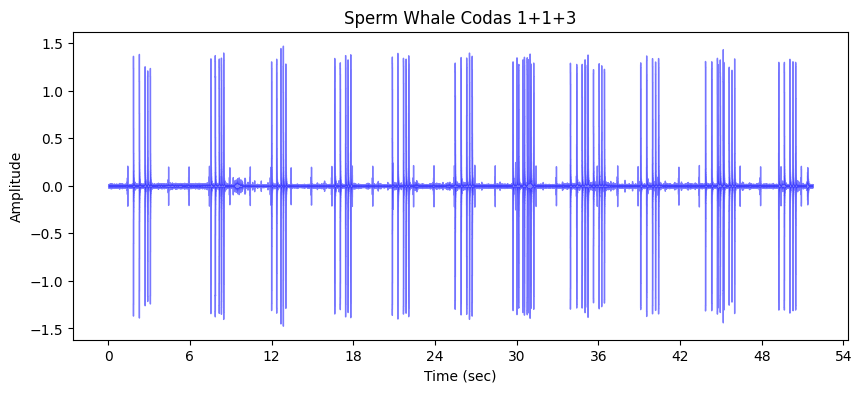

In [14]:
plotWaveform(spermwhale, 'Sperm Whale Codas 1+1+3')

In [15]:
FRAME_LENGTH = 400 # in milliseconds
FRAME_SHIFT = 250 # in milliseconds, same concept as hop length
ENERGY_THRESHOLD = 0.5 # Energy above this threshold is classified as speech
PRE_EMPHASIS = 0 # Boost the energy of high-frequencies

In [16]:
vad = EnergyVAD(frame_length = FRAME_LENGTH, frame_shift = FRAME_SHIFT, sample_rate = SR, energy_threshold = ENERGY_THRESHOLD)

In [17]:
# array returned by VAD has one element per frame, and each element is a boolean indicating 
# if above energy threshold or not
voice_activity_spermwhale = vad(spermwhale)

In [18]:
coda_timestamps = convert_vad_output_to_timestamps(voice_activity_spermwhale, FRAME_LENGTH, FRAME_SHIFT)
coda_timestamps # check them

[{'start': '1.500', 'end': '3.650'},
 {'start': '7.250', 'end': '8.900'},
 {'start': '11.750', 'end': '13.650'},
 {'start': '16.250', 'end': '18.400'},
 {'start': '20.500', 'end': '22.650'},
 {'start': '25.250', 'end': '27.150'},
 {'start': '29.500', 'end': '31.650'},
 {'start': '33.750', 'end': '36.900'},
 {'start': '38.750', 'end': '40.900'},
 {'start': '43.500', 'end': '46.400'},
 {'start': '49.000', 'end': '50.900'}]

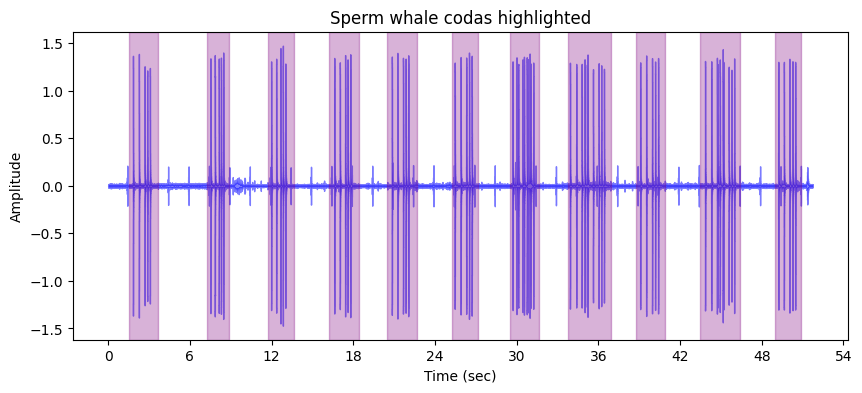

In [19]:
plotWaveform(spermwhale, 'Sperm whale codas highlighted', coda_timestamps)

In [20]:
# Separate each coda into it's own var and trim off silence at beginning and end
codas = splitAudioByTimestamps(spermwhale, coda_timestamps)
len(codas)

11

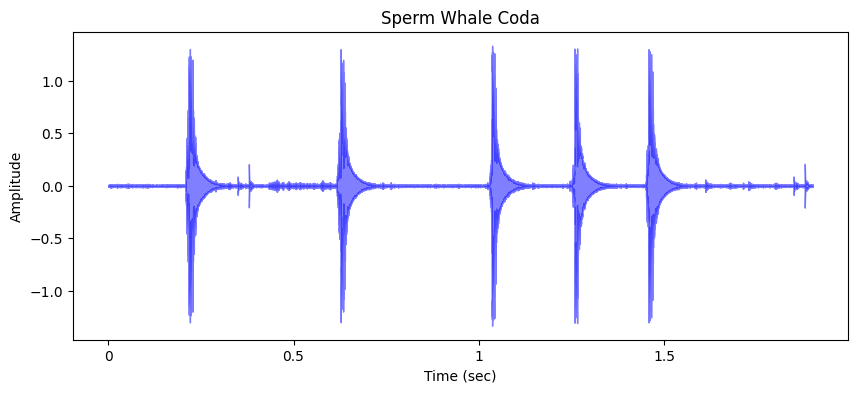

In [21]:
# Plot waveform for one of the coda's
plotWaveform(codas[10], 'Sperm Whale Coda')

## Extract features from sperm whale codas in sequence
Some features can be fed into a machine learning algorithm or rule-based model to transcribe the sperm whale conversation by coda type and rhythm for more information, see https://www.nature.com/articles/s41467-024-47221-8

Data structure will have:
One column for each coda, in sequence
One row for metadata that will identify each coda, including:
1. Vad output
2. Timestamps of the clicks
3. Timestamps of the silences
4. Number of clicks
5. Total duration of coda (time between beginning of first click and end of last click in seconds)
6. Inter-click durations (an array, starting with the time between the first and second click in seconds)

In [22]:
# Get VAD output for a coda, which requires similar energy threshold but smaller frames
FRAME_LENGTH = 20 # in milliseconds
FRAME_SHIFT = 15 # in milliseconds, same concept as hop length
ENERGY_THRESHOLD = 0.2 # Energy above this threshold is classified as speech
PRE_EMPHASIS = 0.9 # Boost the energy of high-frequencies
def extract_vad_on_coda(coda):
    vad = EnergyVAD(frame_length = FRAME_LENGTH, frame_shift = FRAME_SHIFT, sample_rate = SR, energy_threshold = ENERGY_THRESHOLD)
    return vad(coda)

def extract_data_on_codas(codas):
    # Since the inter-click-intervals are an array of different sizes for different codas, use a pandas dataframe
    # rather than a 2D NumPu array which would require all elements to be the same data type
    # List of row labels
    row_labels = ['VAD output', 'Timestamps for clicks', 'Timestamps for silences', 'Number of clicks', 'Duration', 'Inter-Click Intervals']

    # Create an empty DataFrame with row labels
    df = pd.DataFrame(index=row_labels)
    #
    
    for i, coda in enumerate(codas):
        col = []
        # extract vad from coda
        vad = extract_vad_on_coda(coda)
        col.append(vad)
        
        # Use VAD output to extract timestamps of the clicks
        timestamps_for_clicks = convert_vad_output_to_timestamps(vad, FRAME_LENGTH, FRAME_SHIFT)
        col.append(timestamps_for_clicks)

        # Use VAD output to extract timestamps of the silences
        timestamps_for_silences = convert_vad_output_to_timestamps(vad, FRAME_LENGTH, FRAME_SHIFT, 0)
        col.append(timestamps_for_silences)

        # Use timestamps of the clicks to find the total number of clicks
        num_of_clicks = len(timestamps_for_clicks)
        col.append(num_of_clicks)

        # Use timestamps of the clicks to find total duration of the coda (time from beginning of first click
        # to end of last click)
        duration = float(timestamps_for_clicks[len(timestamps_for_clicks)-1]['end']) - float(timestamps_for_clicks[0]['start'])
        col.append(duration)

        # Get the inter-click-interval durations in seconds
        icis = convert_timestamps_to_durations(timestamps_for_silences[1:-1])
        col.append(icis)

        # Add the current column to the DataFrame
        df[i] = col  # Create a unique column for each coda

    return df

In [23]:
# Extract metadata on each of the 11 codas from the sperm whale conversation, and display data
df_codas = extract_data_on_codas(codas)
df_codas

,0,1,2,3,4,5,6,7,8,9,10
VAD output,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
Timestamps for clicks,"[{'start': '0.315', 'end': '0.365'}, {'start':...","[{'start': '0.240', 'end': '0.305'}, {'start':...","[{'start': '0.210', 'end': '0.275'}, {'start':...","[{'start': '0.345', 'end': '0.410'}, {'start':...","[{'start': '0.315', 'end': '0.380'}, {'start':...","[{'start': '0.180', 'end': '0.245'}, {'start':...","[{'start': '0.180', 'end': '0.245'}, {'start':...","[{'start': '0.150', 'end': '0.215'}, {'start':...","[{'start': '0.315', 'end': '0.380'}, {'start':...","[{'start': '0.315', 'end': '0.380'}, {'start':...","[{'start': '0.195', 'end': '0.260'}, {'start':..."
Timestamps for silences,"[{'start': '0.000', 'end': '0.335'}, {'start':...","[{'start': '0.000', 'end': '0.260'}, {'start':...","[{'start': '0.000', 'end': '0.230'}, {'start':...","[{'start': '0.000', 'end': '0.365'}, {'start':...","[{'start': '0.000', 'end': '0.335'}, {'start':...","[{'start': '0.000', 'end': '0.200'}, {'start':...","[{'start': '0.000', 'end': '0.200'}, {'start':...","[{'start': '0.000', 'end': '0.170'}, {'start':...","[{'start': '0.000', 'end': '0.335'}, {'start':...","[{'start': '0.000', 'end': '0.335'}, {'start':...","[{'start': '0.000', 'end': '0.215'}, {'start':..."
Number of clicks,5,5,5,5,5,5,10,9,5,9,5
Duration,1.295,1.01,1.1,1.235,1.28,1.325,1.58,2.555,1.385,2.21,1.31
Inter-Click Intervals,"[0.425, 0.395, 0.17, 0.2]","[0.305, 0.26, 0.14, 0.14]","[0.35, 0.29, 0.155, 0.155]","[0.38, 0.365, 0.155, 0.17]","[0.395, 0.38, 0.17, 0.17]","[0.41, 0.395, 0.185, 0.17]","[0.275, 0.11, 0.29, 0.08, 0.17, 0.08, 0.08, 0....","[0.44, 0.365, 0.185, 0.14, 0.38, 0.41, 0.185, ...","[0.41, 0.41, 0.2, 0.185]","[0.44, 0.395, 0.14, 0.2, 0.035, 0.38, 0.185, 0...","[0.395, 0.38, 0.2, 0.17]"


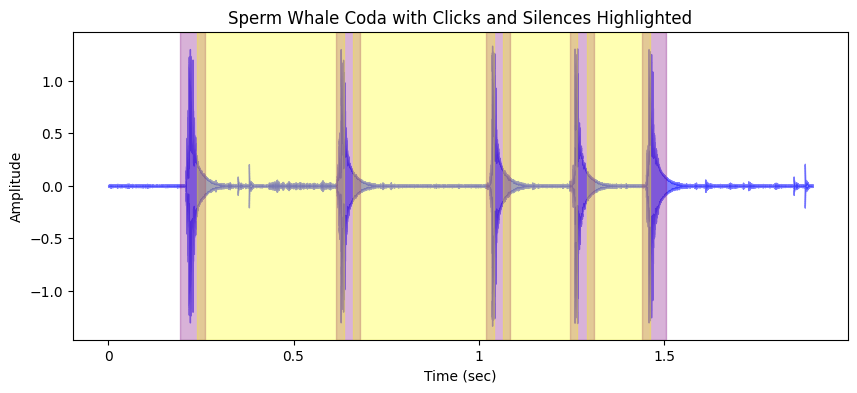

In [24]:
# Check the timestamps for clicks and silences on one of the codas via a waveform
coda = 10
plotWaveform(codas[coda], 'Sperm Whale Coda with Clicks and Silences Highlighted', df_codas[coda]['Timestamps for clicks'], df_codas[coda]['Timestamps for silences'][1:-1])

## Next steps: 
Additional work could be done to identify which sperm whale is making the coda (speaker diarization) and separate out the coda's that overlap.
Then, metadata such as the number of clicks, duration, and ICI's could be fed into a classifier model, to label each coda and thus transcribe the sperm whale conversation
This file only had 1+1+3, but the methods should work to identify other coda patterns